# 18 — Convergence Curve Plots

**Maps to:** `report/Chapters/Task4.tex` §`T4:Convergence`.  
**Ticket:** TICKET-18.

Convergence curves showing mean ± 1 std of best fitness over generations,
grouped by constraint-handling strategy. Data sourced from TICKET-17's
comparative experiment (repair vs. no-repair, 30 seeds each).

> **Note:** Per-configuration convergence plots (from TICKET-16 parameter
> sweep) will be added once that data is available.

---
## Setup

In [1]:
%run ./15_experiment_runner.ipynb

Loaded kroA100: 100 cities


Best fitness : 84458.32
Known optimal: 21282
Gap          : 296.9%
Wall time    : 0.2s

Per-generation log (first 5 rows):
Saved: ../results/9e9a3301_seed0042.csv
Size : 11,657 bytes
Shape: (101, 16)
Cols : ['generation', 'best_fitness', 'mean_fitness', 'diversity', 'pop_size', 'n_generations', 'crossover_rate', 'mutation_rate', 'tournament_k', 'elitism_count', 'selection_method', 'crossover_method', 'mutation_method', 'repair_enabled', 'repair_strategy', 'seed']
Grid: 6 configurations
  976d5e2d | xover=pmx seed=1
  976d5e2d | xover=pmx seed=2
  976d5e2d | xover=pmx seed=3
  0fc01629 | xover=ox seed=1
  0fc01629 | xover=ox seed=2
  0fc01629 | xover=ox seed=3
Total: 6 | Completed: 6 | Pending: 0
Nothing to run — all results already exist.
Re-running the same grid (all should be skipped):
Total: 6 | Completed: 6 | Pending: 0
Nothing to run — all results already exist.


In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.figsize": (8, 5),
    "figure.constrained_layout.use": True,
})

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

---
## Load Benchmark and Rebuild Configs

Reconstruct the same experiment configs from TICKET-17 so we can locate
their result CSVs.

In [3]:
coords, dist_matrix = load_tsp(Path("../data/TSP-dataset/kroA100.tsp"))
n_cities = dist_matrix.shape[0]
OPTIMAL = 21282

N_SEEDS = 30
SEEDS = list(range(1, N_SEEDS + 1))

BASE_CONFIG = {
    "pop_size": 100,
    "n_generations": 500,
    "crossover_rate": 0.8,
    "mutation_rate": 0.2,
    "tournament_k": 3,
    "elitism_count": 2,
    "selection_method": "tournament",
    "crossover_method": "naive",
    "mutation_method": "swap",
}

strategies = {
    "repair": {"repair_enabled": True, "repair_strategy": "random"},
    "no_repair": {"repair_enabled": False, "repair_strategy": "random"},
}

configs = {}
for name, overrides in strategies.items():
    configs[name] = build_grid(
        param_grid={k: [v] for k, v in overrides.items()},
        seeds=SEEDS,
        base=BASE_CONFIG,
    )

print(f"Configs per strategy: {', '.join(f'{k}={len(v)}' for k, v in configs.items())}")

Configs per strategy: repair=30, no_repair=30


---
## Load Per-Generation Data

Load all result CSVs and combine into a single DataFrame with strategy
labels.

In [4]:
def load_gen_data(config_list, label):
    frames = []
    for c in config_list:
        path = result_path(c)
        if not path.exists():
            continue
        df = pd.read_csv(path)[["generation", "best_fitness", "mean_fitness", "diversity"]].copy()
        df["seed"] = c.seed
        df["strategy"] = label
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

data = pd.concat([
    load_gen_data(configs["repair"], "Repair"),
    load_gen_data(configs["no_repair"], "No Repair"),
], ignore_index=True)

print(f"Total rows: {len(data):,}")
print(f"Strategies: {data['strategy'].unique()}")
print(f"Seeds per strategy: {data.groupby('strategy')['seed'].nunique().to_dict()}")

Total rows: 30,060
Strategies: <ArrowStringArray>
['Repair', 'No Repair']
Length: 2, dtype: str
Seeds per strategy: {'No Repair': 30, 'Repair': 30}


---
## Plot 1 — Best Fitness Convergence

Mean best fitness ± 1 standard deviation across 30 seeds, per strategy.
The shaded band shows the inter-run variability.

Saved: ../results/figures/convergence_best_fitness.pdf


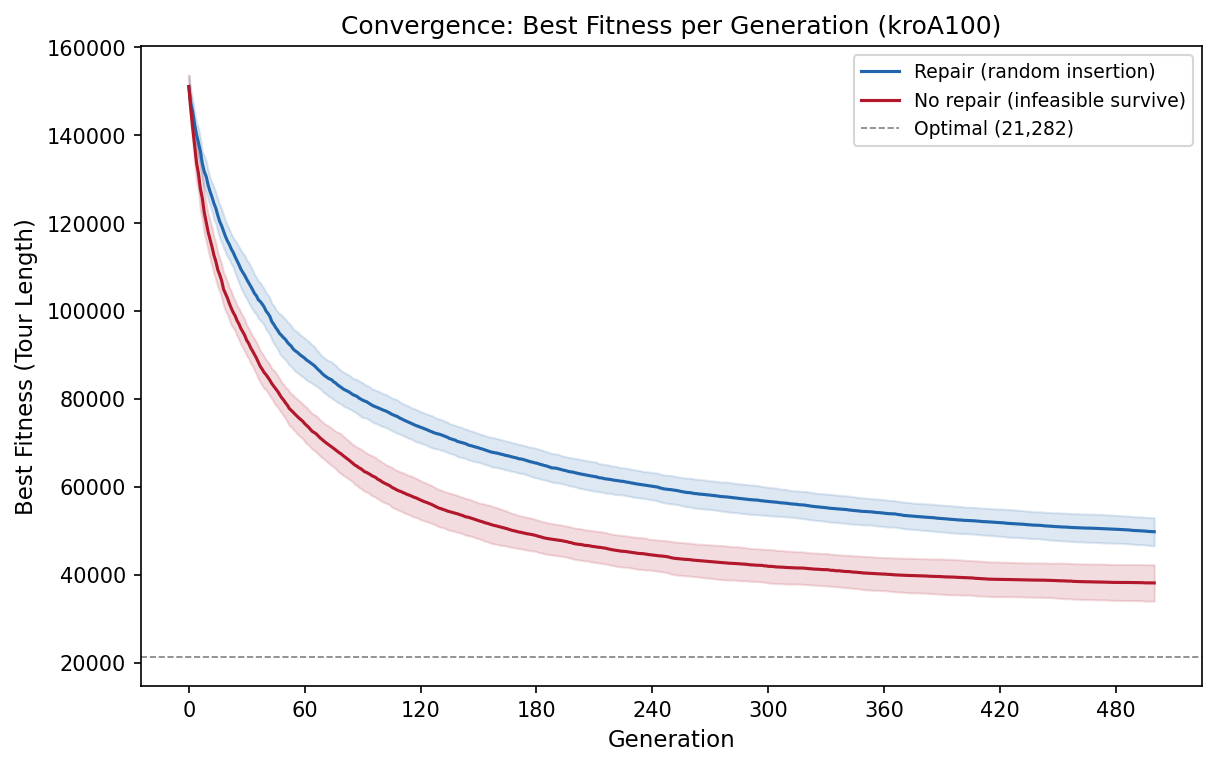

In [5]:
STRATEGY_STYLE = {
    "Repair": {"color": "#2166ac", "label": "Repair (random insertion)"},
    "No Repair": {"color": "#b2182b", "label": "No repair (infeasible survive)"},
}

fig, ax = plt.subplots()

for strategy, style in STRATEGY_STYLE.items():
    subset = data[data["strategy"] == strategy]
    agg = subset.groupby("generation")["best_fitness"].agg(["mean", "std"]).reset_index()

    ax.plot(agg["generation"], agg["mean"],
            color=style["color"], linewidth=1.5, label=style["label"])
    ax.fill_between(agg["generation"],
                    agg["mean"] - agg["std"],
                    agg["mean"] + agg["std"],
                    color=style["color"], alpha=0.15)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness (Tour Length)")
ax.set_title("Convergence: Best Fitness per Generation (kroA100)")
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

path = FIGURES_DIR / "convergence_best_fitness.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Plot 2 — Mean Population Fitness Convergence

Mean of the population-average fitness across 30 seeds. This shows how the
overall population quality evolves, not just the best individual.

Saved: ../results/figures/convergence_mean_fitness.pdf


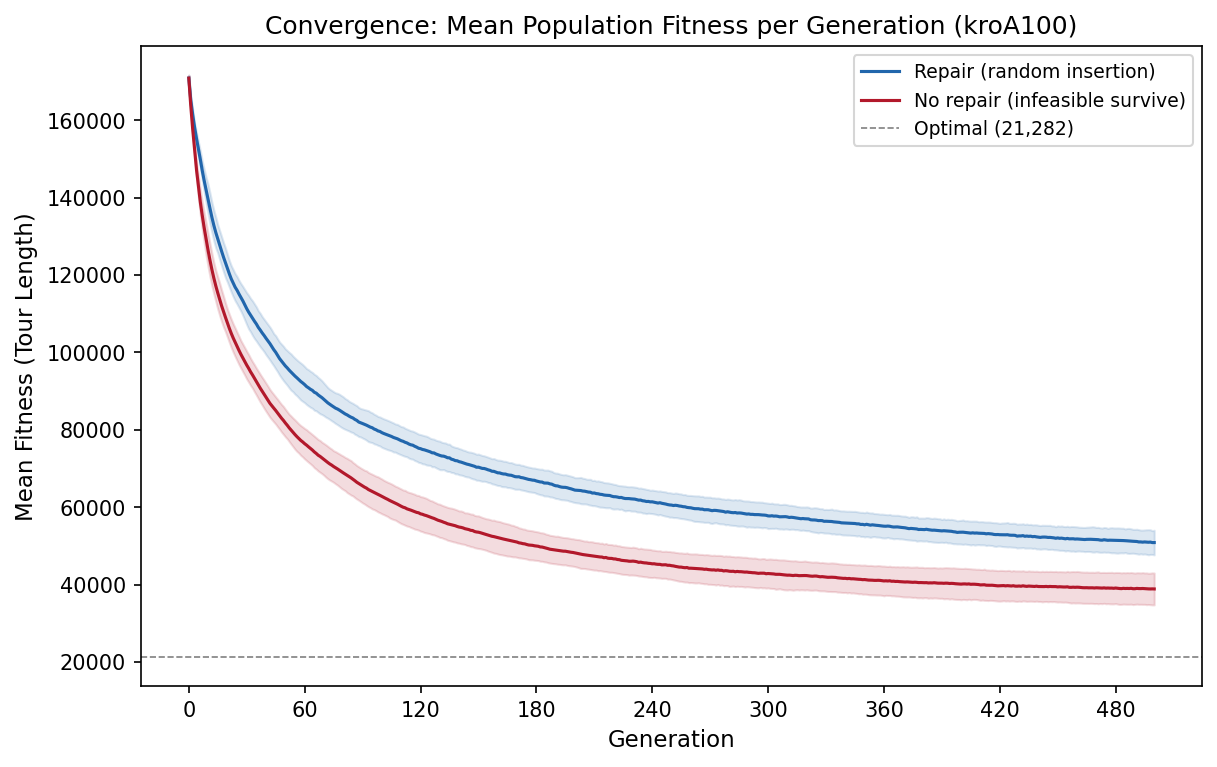

In [6]:
fig, ax = plt.subplots()

for strategy, style in STRATEGY_STYLE.items():
    subset = data[data["strategy"] == strategy]
    agg = subset.groupby("generation")["mean_fitness"].agg(["mean", "std"]).reset_index()

    ax.plot(agg["generation"], agg["mean"],
            color=style["color"], linewidth=1.5, label=style["label"])
    ax.fill_between(agg["generation"],
                    agg["mean"] - agg["std"],
                    agg["mean"] + agg["std"],
                    color=style["color"], alpha=0.15)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8, label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Generation")
ax.set_ylabel("Mean Fitness (Tour Length)")
ax.set_title("Convergence: Mean Population Fitness per Generation (kroA100)")
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

path = FIGURES_DIR / "convergence_mean_fitness.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Plot 3 — Population Diversity Over Generations

Normalised pairwise Hamming distance (0 = all identical, 1 = maximally
diverse). Shows how quickly the population converges under each strategy.

Saved: ../results/figures/convergence_diversity.pdf


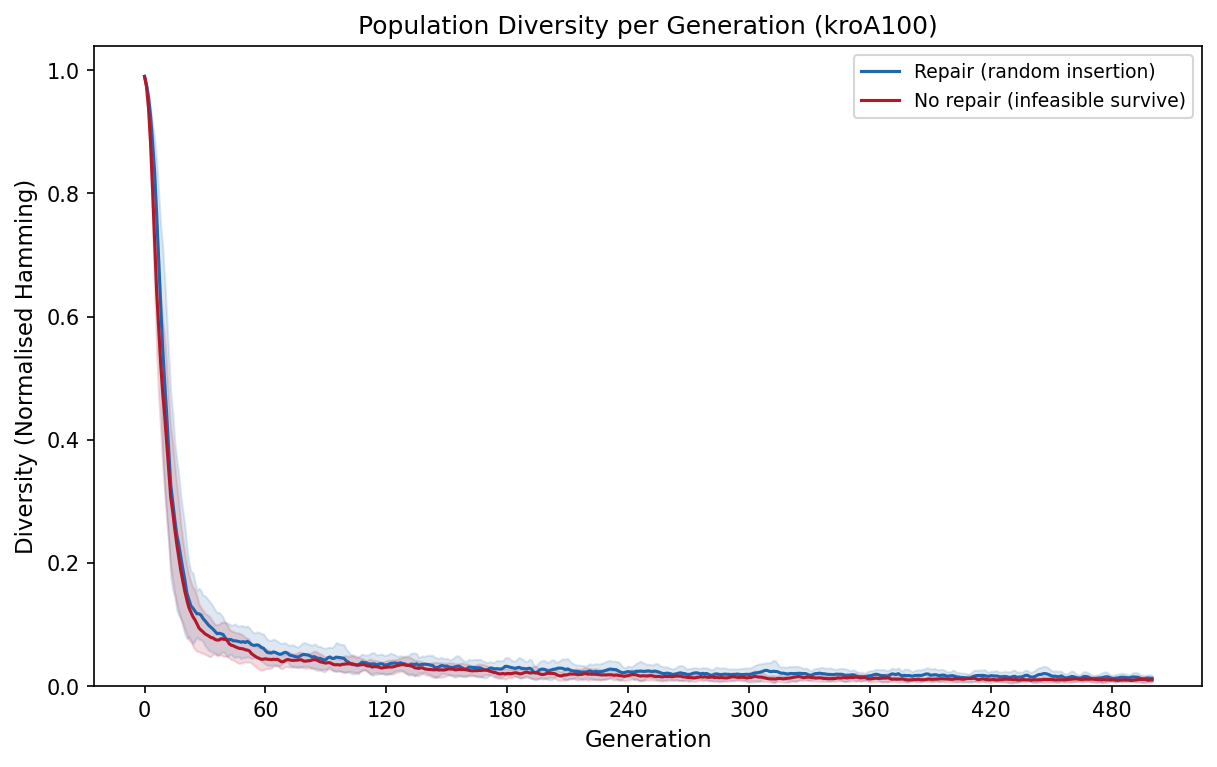

In [7]:
fig, ax = plt.subplots()

for strategy, style in STRATEGY_STYLE.items():
    subset = data[data["strategy"] == strategy]
    agg = subset.groupby("generation")["diversity"].agg(["mean", "std"]).reset_index()

    ax.plot(agg["generation"], agg["mean"],
            color=style["color"], linewidth=1.5, label=style["label"])
    ax.fill_between(agg["generation"],
                    agg["mean"] - agg["std"],
                    agg["mean"] + agg["std"],
                    color=style["color"], alpha=0.15)

ax.set_xlabel("Generation")
ax.set_ylabel("Diversity (Normalised Hamming)")
ax.set_title("Population Diversity per Generation (kroA100)")
ax.legend(loc="upper right")
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

path = FIGURES_DIR / "convergence_diversity.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Plot 4 — Combined Three-Panel Figure

All three metrics in a single figure for the report. Compact layout
suitable for a full-width figure in the IEEE template.

Saved: ../results/figures/convergence_combined.pdf


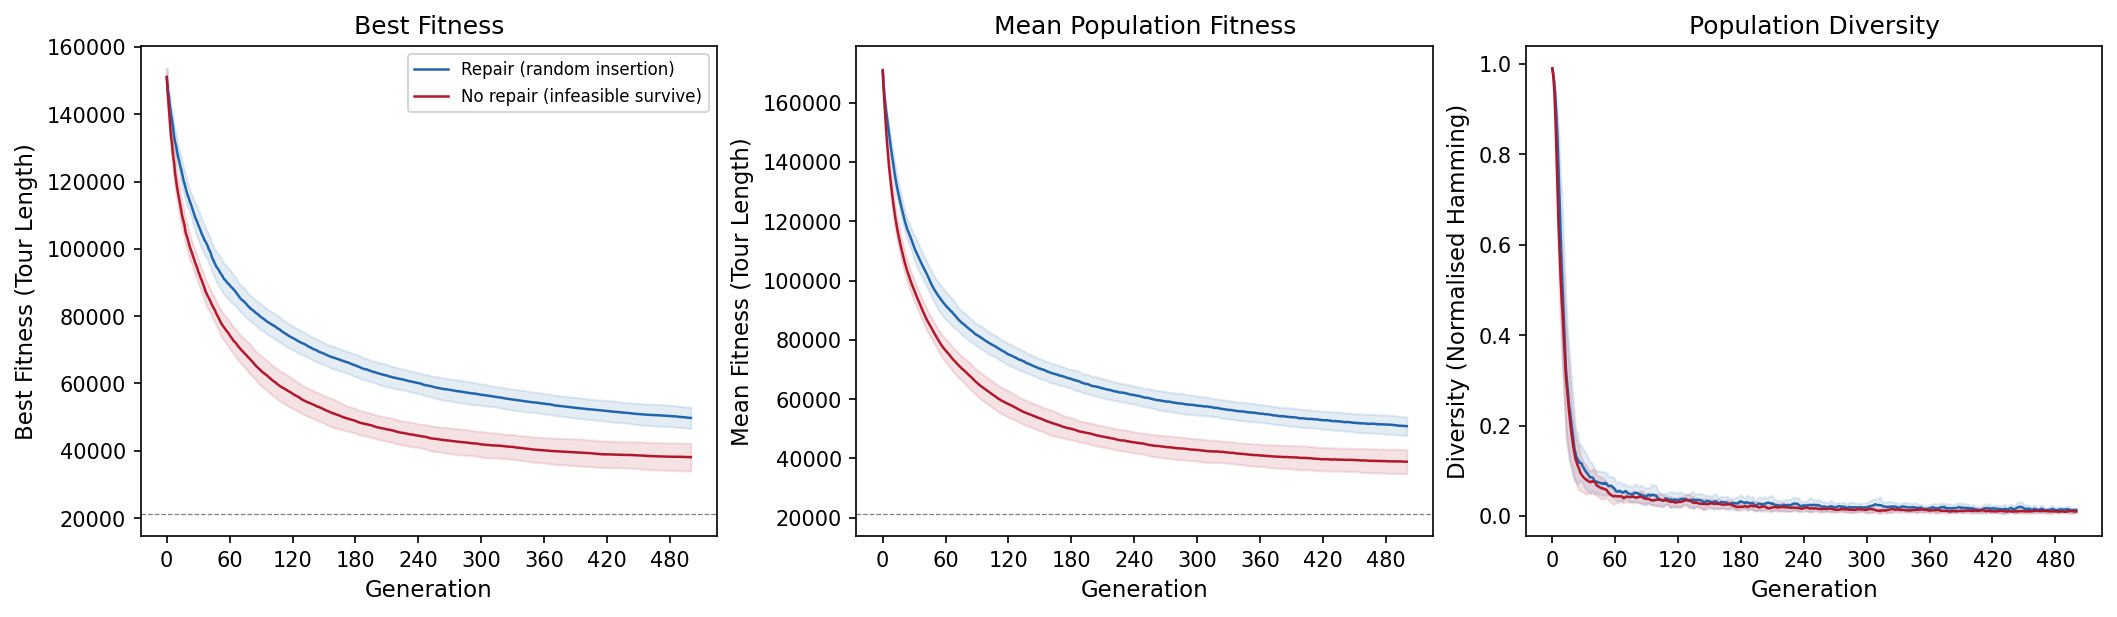

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = [
    ("best_fitness", "Best Fitness (Tour Length)", "Best Fitness"),
    ("mean_fitness", "Mean Fitness (Tour Length)", "Mean Population Fitness"),
    ("diversity", "Diversity (Normalised Hamming)", "Population Diversity"),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    for strategy, style in STRATEGY_STYLE.items():
        subset = data[data["strategy"] == strategy]
        agg = subset.groupby("generation")[col].agg(["mean", "std"]).reset_index()

        ax.plot(agg["generation"], agg["mean"],
                color=style["color"], linewidth=1.2, label=style["label"])
        ax.fill_between(agg["generation"],
                        agg["mean"] - agg["std"],
                        agg["mean"] + agg["std"],
                        color=style["color"], alpha=0.12)

    if col != "diversity":
        ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.6)

    ax.set_xlabel("Generation")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

axes[0].legend(loc="upper right", fontsize=8)

path = FIGURES_DIR / "convergence_combined.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

---
## Summary

This notebook produces four convergence figures from TICKET-17's
comparative experiment data (repair vs. no-repair, 30 seeds × 500
generations on kroA100):

1. **Best fitness convergence** — shows the repair arm converges to higher
   but *meaningful* fitness values, while no-repair converges to artificially
   low values (invalid tours).
2. **Mean population fitness** — shows overall population quality trends.
3. **Diversity over generations** — shows how quickly genetic diversity
   collapses under each strategy.
4. **Combined three-panel** — publication-ready figure for the report.

All figures saved to `results/figures/` at 300 DPI in PDF format.

> **To add after TICKET-16:** Per-configuration convergence plots showing
> how different parameter settings (pop_size, crossover_rate, etc.) affect
> convergence behaviour.